In [1]:
import numpy as np

import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import struct
import jax.numpy as jnp
import jax
import seaborn
import scienceplots

plt.style.use(['science','notebook'])


jax.config.update("jax_enable_x64", True)

In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
@jax.jit
def Energy_spectra(x):
  return jnp.histogram(k.ravel(),bins = shells,weights = x.ravel())[0]

In [4]:
pi = jnp.pi
N = 2**9

L = 2*pi
dx = L/N

nu = 1e-3
kvals = np.arange(0,N//2)

# ----------------------------------------
# Spectral Grid Setup (Memory-Efficient)
# ----------------------------------------

kx , ky , kz  = np.meshgrid(jnp.fft.fftfreq(N, dx)*(2*pi),jnp.fft.fftfreq(N, dx)*(2*pi), jnp.fft.rfftfreq(N, dx)*(2*pi),indexing= 'ij')

k_vec = np.stack([kx,ky,kz])

k_sq = (k_vec[0]**2 + k_vec[1]**2 + k_vec[2]**2)

k = np.sqrt(k_sq)

derivative_operator = 1j*k_vec

shells = np.arange(-0.5, N//2 + 1 , 1.)
shells[0] = 0.
# ----------------------------------------
# Dealiasing and Projection Utilities
# ----------------------------------------

alias_mask = (abs(k_vec[0])<=N//3)*(abs(k_vec[1])<=N//3)*(abs(k_vec[2])<=N//3)

k_over_k_sq = np.where(k_sq == 0 , 0 ,  k_vec/k_sq)*alias_mask

kint = np.clip(np.round(k,0).astype(int),None,N//2)

/var/folders/br/q1r8zd1d6z50qx6y9z0kdpk00000gn/T/ipykernel_2530/3393664484.py:32: RuntimeWarning: invalid value encountered in divide
  k_over_k_sq = np.where(k_sq == 0 , 0 ,  k_vec/k_sq)*alias_mask


In [5]:
####################################################################################
'''
Helping Function: 1.curl-free projection, 2.divergence  3.curl
'''
####################################################################################
@jax.jit
def divergence(u):

  return jnp.sum(derivative_operator*u,0)

# Converting Data From .out to .npz Files

In [6]:
# u_real = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Fractal_velocity_field_Real/Decimated_Fractal_D_2p90.out')

# ux = np.reshape(u_real[:,0], shape = (N,N,N), order = "A")   
# uy = np.reshape(u_real[:,1], shape = (N,N,N), order = "A")   
# uz = np.reshape(u_real[:,2], shape = (N,N,N), order = "A")   

# u_real = np.array([ux,uy,uz])
# np.savez('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Fractal_velocity_field_Real/Decimated_Fractal_D_2p90.npz',u_real = u_real)

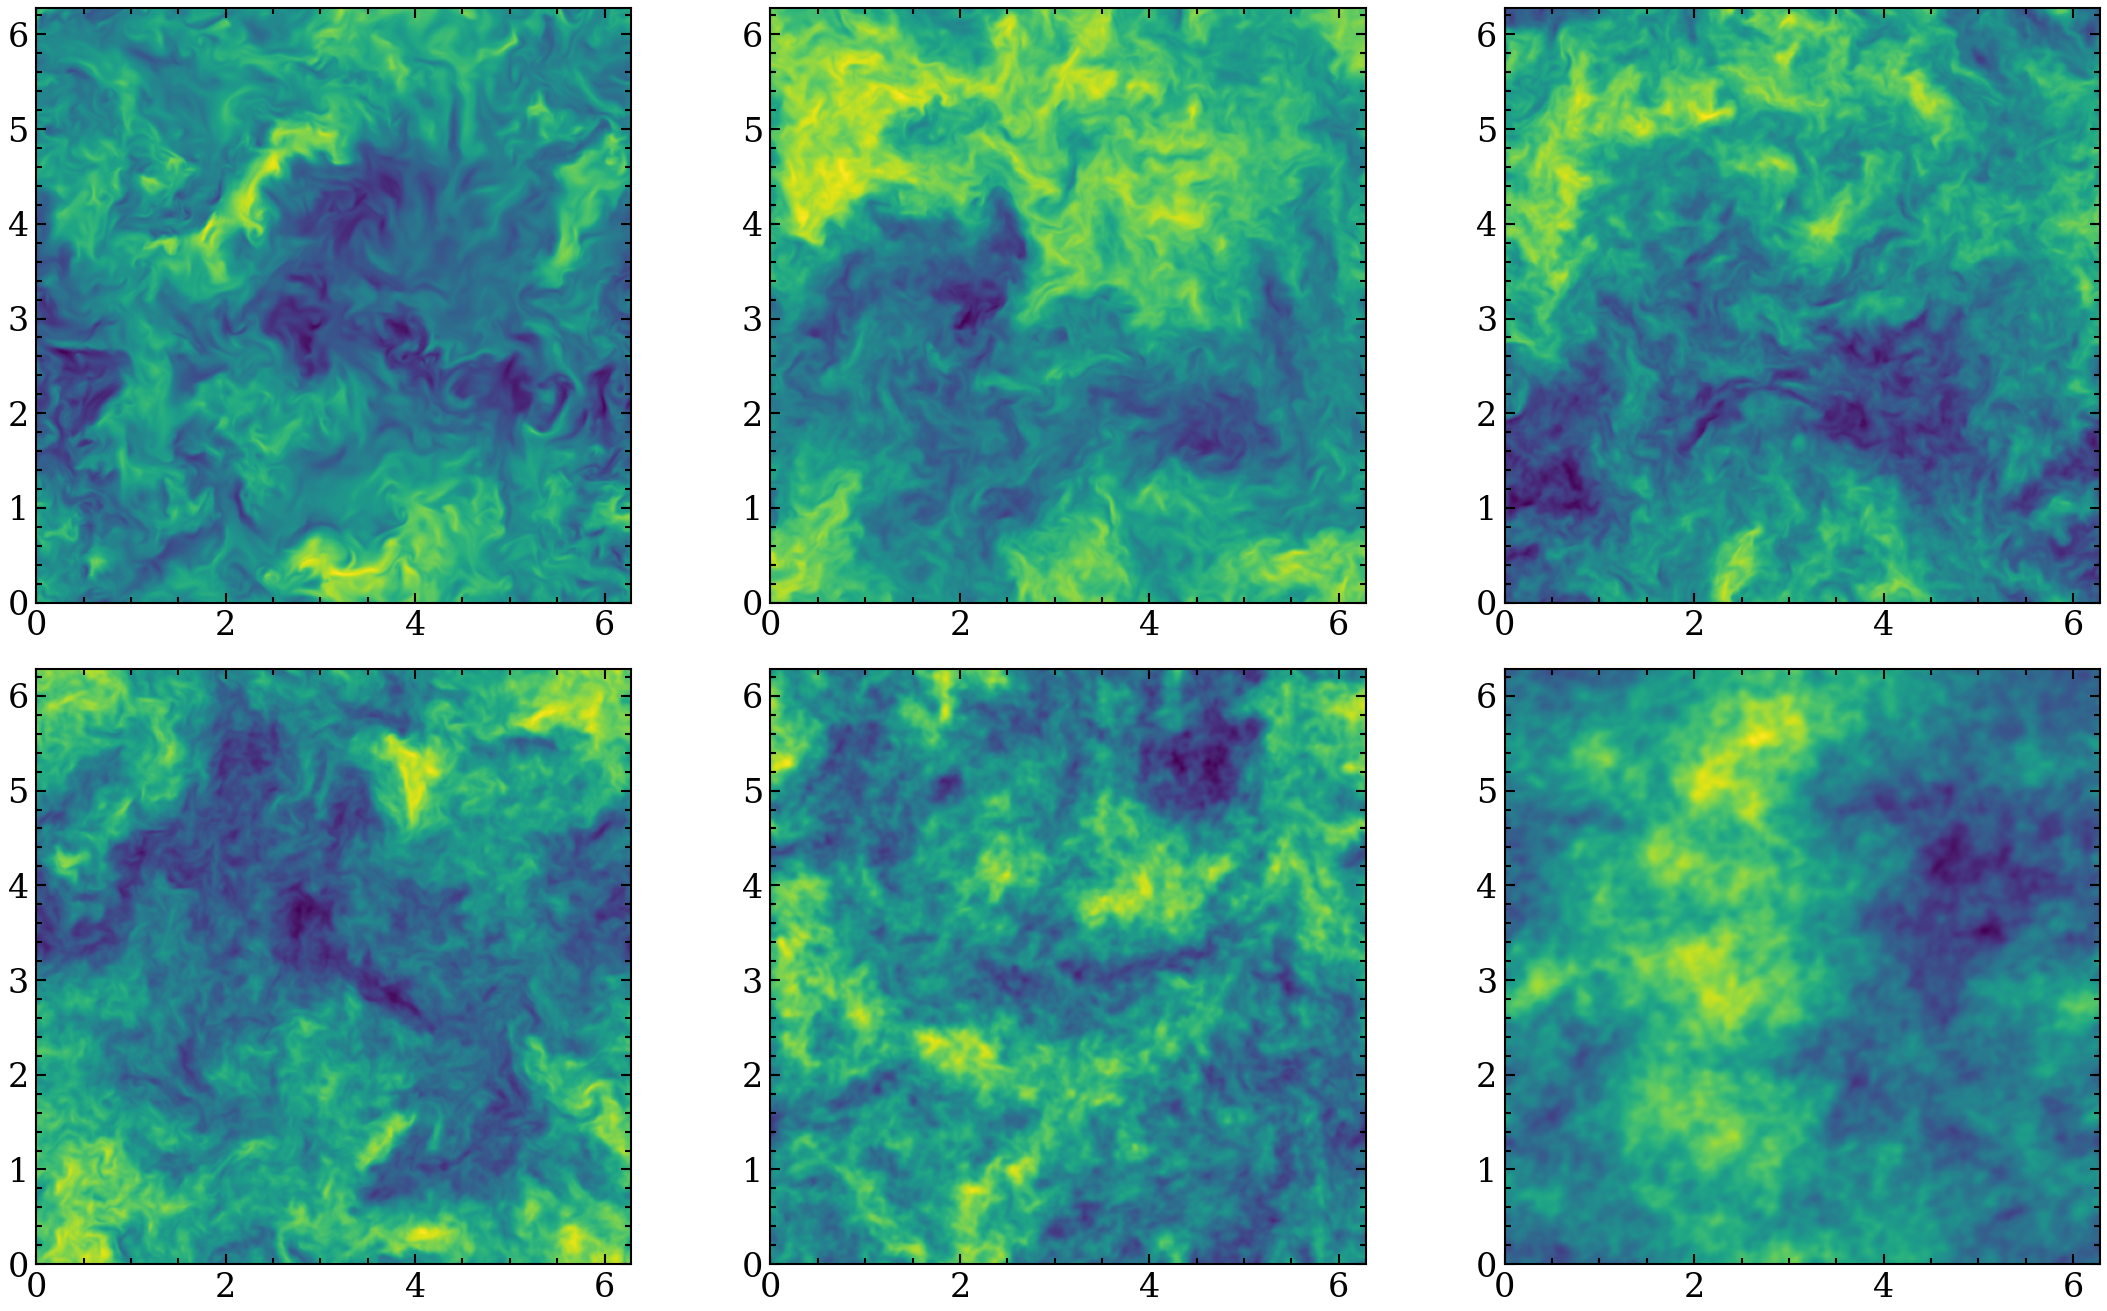

In [86]:
# Create 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 9), dpi=150)

u_real = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Homogeneous_Velocityfield_Real/Decimated_Homogeneous_P0p0.npz')['u_real']
axes[0,0].imshow(u_real[1,:,23,:].T, origin = 'lower' , extent = [0,L,0,L],cmap = 'viridis')

u_real = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Homogeneous_Velocityfield_Real/Decimated_Homogeneous_P0p03.npz')['u_real']
axes[0,1].imshow(u_real[1,:,23,:].T, origin = 'lower' , extent = [0,L,0,L],cmap = 'viridis')

u_real = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Homogeneous_Velocityfield_Real/Decimated_Homogeneous_P0p05.npz')['u_real']
axes[0,2].imshow(u_real[1,:,23,:].T, origin = 'lower' , extent = [0,L,0,L],cmap = 'viridis')

u_real = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Homogeneous_Velocityfield_Real/Decimated_Homogeneous_P0p07.npz')['u_real']
axes[1,0].imshow(u_real[1,:,23,:].T, origin = 'lower' , extent = [0,L,0,L],cmap = 'viridis')


u_real = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Homogeneous_Velocityfield_Real/Decimated_Homogeneous_P0p3.npz')['u_real']
axes[1,1].imshow(u_real[1,:,23,:].T, origin = 'lower' , extent = [0,L,0,L],cmap = 'viridis')

u_real = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Homogeneous_Velocityfield_Real/Decimated_Homogeneous_P0p5.npz')['u_real']
axes[1,2].imshow(u_real[1,:,23,:].T, origin = 'lower' , extent = [0,L,0,L],cmap = 'viridis')

plt.tight_layout()
plt.show()

# Energy Spectra

In [7]:
normalize = np.where((k_vec[2] == 0) + (k_vec[2] == N//2) , 1/N**6,2/N**6)

In [7]:
u_real = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Homogeneous_Velocityfield_Real/Decimated_Homogeneous_P0p0.npz')['u_real']
u_spec = np.fft.rfftn(u_real, axes = (1,2,3))
print("MAX divergence:", np.abs(np.fft.irfftn(divergence(u_spec))).max())
# np.savez('Spectra_Decimated_Fractal_D2p80.npz',E_k = E_k_arr)

MAX divergence: 3.967708672242157e-12


In [6]:
# HOMOGENEOUS

E_k_arr = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p0.npz')['E_k']])

E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p03.npz')['E_k']],axis =0)
 
E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p05.npz')['E_k']],axis =0)

E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p07.npz')['E_k']],axis =0)


E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p1.npz')['E_k']],axis =0)

E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p3.npz')['E_k']],axis =0)

E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p5.npz')['E_k']],axis =0)


# Fractal


E_k_arr_fractal = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D3p00.npz')['E_k']])

E_k_arr_fractal  = np.append(E_k_arr_fractal , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D2p98.npz')['E_k']],axis =0)
 
E_k_arr_fractal  = np.append(E_k_arr_fractal , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D2p95.npz')['E_k']],axis =0)

E_k_arr_fractal  = np.append(E_k_arr_fractal , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D2p90.npz')['E_k']],axis =0)

E_k_arr_fractal  = np.append(E_k_arr_fractal , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D2p80.npz')['E_k']],axis =0)


print(E_k_arr_fractal.shape)

(5, 257)


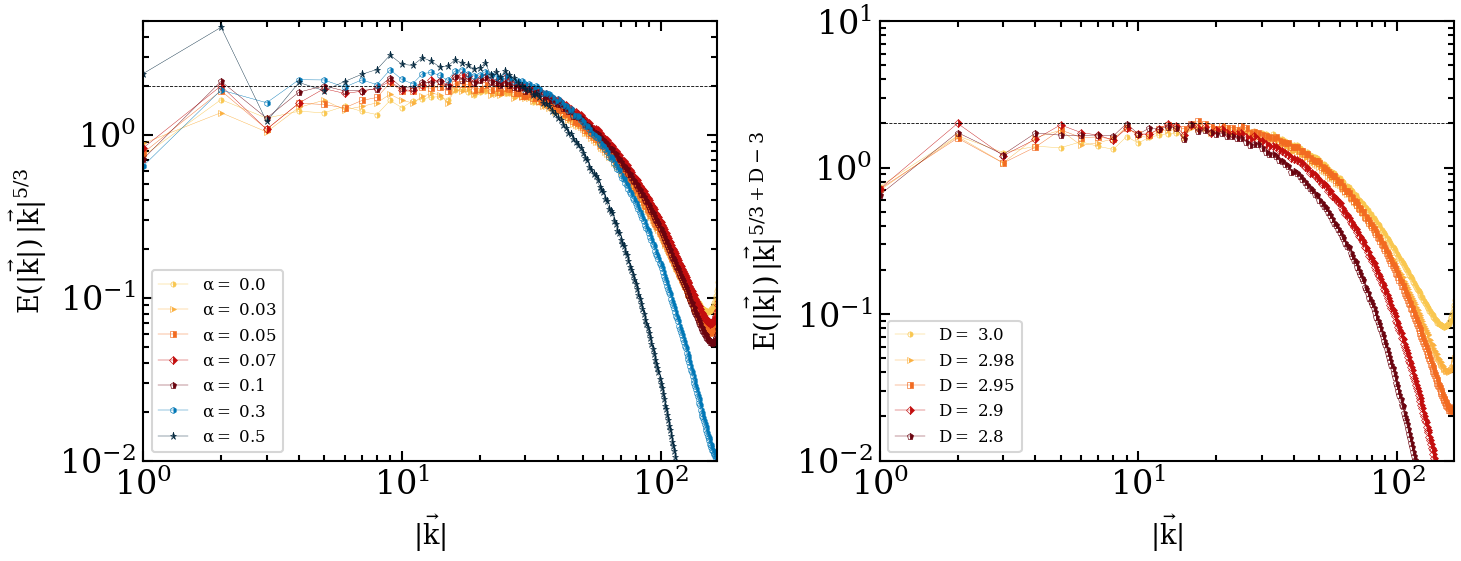

In [10]:
# ---------- Style setup ----------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.frameon': False,
    'mathtext.default': 'regular',
})

# ---------- Figure ----------
fig, ax = plt.subplots(1,2,figsize=(10,4), dpi=150)

ax[0].set_xlabel(r'$|\vec k|$', labelpad=5)
ax[0].set_ylabel(r'$E(|\vec k|) \, |\vec k|^{5/3}$', labelpad=5)
# ax[0].set_title(r'Compensated Energy Spectrum (Homogeneous)', pad=8, fontsize = 9)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]

colors = ['#f9c74f', '#fbb040', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]


markers = ['o', 's', 'D', '*', '^', '.', '<']

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']
ms =  [2.5,3,2.5,2.5,3,3,3.4]

# ---------- Plot curves ----------
for i in range(0,7):
    ax[0].loglog(
        kvals[1:N//3+2],
        (kvals[1:N//3+2] ** (5/3)) * E_k_arr[i, 1:N//3+2],
        marker=markers[i],
        markersize= ms[i],
        linewidth=0.2,
        color=colors[i],
        fillstyle='right',
        label=fr'$\alpha = $ {alphas[i]}',
        markeredgewidth=0.3,   # thinner marker border

    )

# Reference slope (flat for compensated plot)
ax[0].loglog(kvals[1:N//3+2],  2*kvals[1:N//3+2] ** 0, '--', lw=0.4, color='k')
# ax.text(3, 7e2, r'$\propto |\vec k|^0$', fontsize=11, color='black')

# ---------- Limits, scales, and grid ----------
ax[0].set_ylim(1e-2, 5e0)
ax[0].set_xlim(kvals[1], kvals[N//3-5])
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[0].xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax[0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax[0].xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto'))
ax[0].yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto'))
ax[0].xaxis.set_minor_formatter(NullFormatter())
ax[0].yaxis.set_minor_formatter(NullFormatter())

# ---------- Legend ----------
ax[0].legend(
    loc='lower left',
    handlelength=1.8,
    frameon=True,
    prop={'size': 8}
)



# ----------------------------------------

# Fractal Spectra

# ----------------------------------------




ax[1].set_xlabel(r'$|\vec k|$', labelpad=5)
ax[1].set_ylabel(r'$E(|\vec k|) \, |\vec k|^{5/3 + D - 3}$', labelpad=5)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]

colors = ['#f9c74f', '#fbb040', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]

markers = ['o', 's', 'D', '*', '^', '.', '<']

Dimension = [3.00 , 2.98 , 2.95, 2.90 , 2.80]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']
ms =  [2.5,3,2.5,2.5,3,3,3.4]

# ---------- Plot curves ----------
for i in range(0,5):
    ax[1].loglog(
        kvals[1:N//3+2],
        (kvals[1:N//3+2] ** (5/3 + Dimension[i] - 3) ) * E_k_arr_fractal[i, 1:N//3+2],
        marker=markers[i],
        markersize= ms[i],
        linewidth=0.2,
        color=colors[i],
        fillstyle='right',
        label=fr'$D = $ {Dimension[i]}',
        markeredgewidth=0.3,   # thinner marker border

    )

ax[1].loglog(kvals[1:N//3+2],  2*kvals[1:N//3+2] ** 0, '--', lw=0.4, color='k')

# ---------- Limits, scales, and grid ----------

ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_ylim(1e-2, 10e0)
ax[1].set_xlim(kvals[1], kvals[N//3-5])
ax[1].xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax[1].yaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax[1].xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto'))
ax[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto'))
ax[1].xaxis.set_minor_formatter(NullFormatter())
ax[1].yaxis.set_minor_formatter(NullFormatter())

# ---------- Legend ----------
ax[1].legend(
    loc='lower left',
    handlelength=1.8,
    frameon=True,
    prop={'size': 8}
)


# ---------- Save ----------
plt.tight_layout()
plt.savefig('Energy_Spectrum.png', dpi = 800,bbox_inches='tight')
plt.show()


# Enstrpohy Spectra

In [11]:
# HOMOGENEOUS

# avg_dissp = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p0.npz')['avg_dissp']])

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p03.npz')['avg_dissp']],axis =0)
 
# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p05.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p07.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p1.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p3.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p5.npz')['avg_dissp']],axis =0)



# Fractal

avg_dissp = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D3p0.npz')['avg_dissp']])

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p98.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p95.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p90.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p80.npz')['avg_dissp']],axis =0)


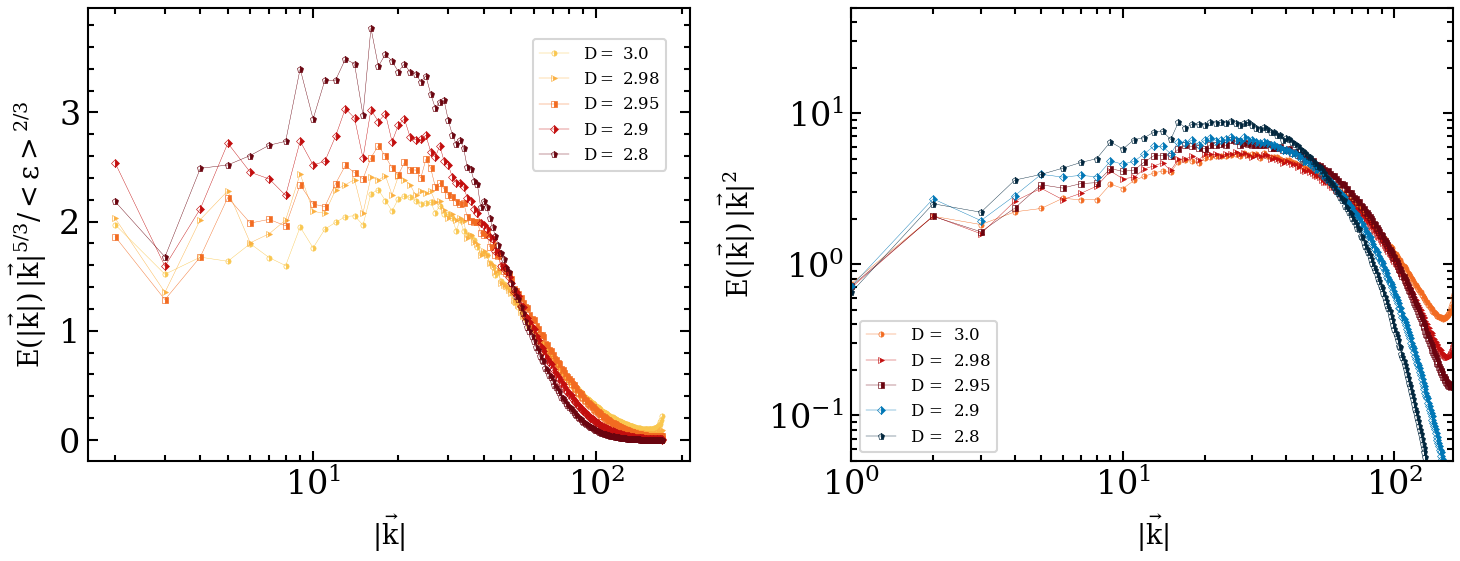

In [33]:
# ---------- Style setup ----------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.frameon': False,
    'mathtext.default': 'regular',
})

# ---------- Figure ----------
fig, ax = plt.subplots(1,2,figsize=(10,4), dpi=150)
Dim = [3.0 , 2.98 , 2.95 , 2.90 , 2.8]

ax[0].set_xlabel(r'$|\vec k|$', labelpad=5)
ax[0].set_ylabel(r'$E(|\vec k|) \, |\vec k|^{5/3}/<\epsilon>^{2/3}$', labelpad=5)
# ax[0].set_title(r'Compensated Energy Spectrum (Homogeneous)', pad=8, fontsize = 9)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]

colors = ['#f9c74f', '#fbb040', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]


markers = ['o', 's', 'D', '*', '^', '.', '<']

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']
ms =  [2.5,3,2.5,2.5,3,3,3.4]

# ---------- Plot curves ----------
for i in range(0,5):
    ax[0].plot(
        kvals[2:N//3+2],
        (kvals[2:N//3+2]**(5/3)*E_k_arr_fractal[i, 2:N//3+2])/(avg_dissp[i])**(2/3),
        marker=markers[i],
        markersize= ms[i],
        linewidth=0.2,
        color=colors[i],
        fillstyle='right',
        label=fr'$D = $ {Dim[i]}',
        markeredgewidth=0.3)


ax[0].set_xscale('log')

# ---------- Legend ----------
ax[0].legend(
    loc='center',
    bbox_to_anchor=(0.85, 0.785),  # (x, y) in axes fraction coordinates
    handlelength=1.8,
    frameon=True,
    prop={'size': 8}
)



# --------------------------------------------------------------------------------





ax[1].set_xlabel(r'$|\vec k|$', labelpad=5)
ax[1].set_ylabel(r'$E(|\vec k|) \, |\vec k|^{2}$', labelpad=5)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]

colors = ['#f9c74f', '#fbb040', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]

markers = ['o', 's', 'D', '*', '^', '.', '<']

Dimension = [3.00 , 2.98 , 2.95, 2.9 , 2.80]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']
ms =  [2.5,3,2.5,2.5,3,3,3.4]

# ---------- Plot curves ----------
for i in range(0,5):
    ax[1].loglog(
        kvals[1:N//3+2],
        kvals[1:N//3+2] **(2) * E_k_arr_fractal[i, 1:N//3+2],
        marker=markers[i],
        markersize= ms[i],
        linewidth=0.2,
        color=colors[i+2],
        fillstyle='right',
        label=fr'$D$ =  {Dimension[i]}',
        markeredgewidth=0.3,   # thinner marker border

    )

ax[1].loglog(kvals[1:N//3+2], 6e2 * kvals[1:N//3+2] ** 0, '--', lw=0.4, color='k')

# ---------- Limits, scales, and grid ----------
ax[1].set_ylim(5e-2, 5e1)
ax[1].set_xlim(kvals[1], kvals[N//3-5])
ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[1].xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax[1].yaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax[1].xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto'))
ax[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto'))
ax[1].xaxis.set_minor_formatter(NullFormatter())
ax[1].yaxis.set_minor_formatter(NullFormatter())

# ---------- Legend ----------
ax[1].legend(
    loc='lower left',
    handlelength=1.8,
    frameon=True,
    prop={'size': 8}
)



# ---------- Save ----------
plt.tight_layout()
plt.savefig('Energy_Spectrum.png', dpi = 800,bbox_inches='tight')
plt.show()


# Singularity Distance From Real-Axis

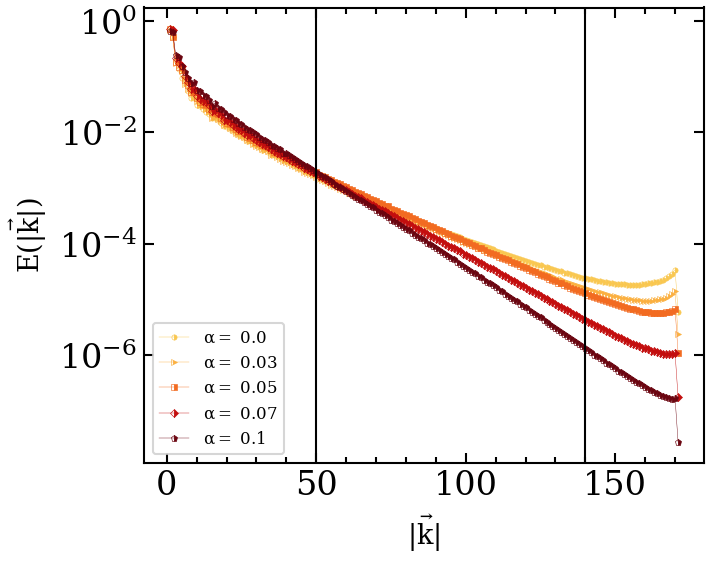

In [64]:
# ---------- Style setup ----------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.frameon': False,
    'mathtext.default': 'regular',
})

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(5,4), dpi=150)

ax.set_xlabel(r'$|\vec k|$', labelpad=5)
ax.set_ylabel(r'$E(|\vec k|)$', labelpad=5)
# ax.set_title(r'Compensated Energy Spectrum (Homogeneous)', pad=8, fontsize = 9)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]

colors = ['#f9c74f', '#fbb040', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]


markers = ['o', 's', 'D', '*', '^', '.', '<']

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']
ms =  [2.5,3,2.5,2.5,3,3,3.4]

# ---------- Plot curves ----------
for i in range(0,5):
    ax.plot(
        kvals[1:N//3+2],
        E_k_arr_fractal[i, 1:N//3+2],
        marker=markers[i],
        markersize= ms[i],
        linewidth=0.2,
        color=colors[i],
        fillstyle='right',
        label=fr'$\alpha = $ {alphas[i]}',
        markeredgewidth=0.3,   # thinner marker border

    )


# ---------- Limits, scales, and grid ----------
# ax.set_ylim(3e1, 5e3)
# ax.set_xlim(kvals[1], kvals[N//3-5])
ax.set_yscale('log')
# ---------- Legend ----------
ax.legend(
    loc='best',
    handlelength=1.8,
    frameon=True,
    prop={'size': 8}
)

# ---------- Save ----------

plt.axvline(50, lw = 1,c = 'black')
plt.axvline(140, lw = 1,c = 'black')

plt.tight_layout()
plt.savefig('Semilog_y_Energy_Spectrum.png', dpi = 800,bbox_inches='tight')
plt.show()


In [67]:
delta_mean = np.zeros(5)
delta_st_dev = np.zeros(5)
    
for i in range(5):   
    
    delta_mean[i] = np.mean(np.gradient(np.log(E_k_arr_fractal[i,30:130]), kvals[30:130]))
    delta_st_dev[i] = np.std(np.gradient(np.log(E_k_arr_fractal[i,30:130]), kvals[30:130]))


np.savetxt("Fractal_delta.out" , jnp.array([Dims , delta_mean, delta_st_dev]).T)

In [35]:
alphas = np.array([0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50])
Dims = np.loadtxt("Energy_spectra/Fractal_Decimation_Vs_C_Kol.out")[:,0]



c_kol_frac = np.loadtxt("Energy_spectra/Fractal_Decimation_Vs_C_Kol.out")[:,1]
c_kol_frac_error = np.loadtxt("Energy_spectra/Fractal_Decimation_Vs_C_Kol.out")[:,2]


c_kol_hom = np.loadtxt("Energy_spectra/Decimation_Vs_C_Kol.out")[:,1]
c_kol_hom_error = np.loadtxt("Energy_spectra/Decimation_Vs_C_Kol.out")[:,2]



delta_frac = np.loadtxt("Energy_spectra/Fractal_delta.out")[:,1]
delta_frac_error = np.loadtxt("Energy_spectra/Fractal_delta.out")[:,2]


delta_hom = np.loadtxt("Energy_spectra/Homogeneous_delta.out")[:,1]
delta_hom_error = np.loadtxt("Energy_spectra/Homogeneous_delta.out")[:,2]

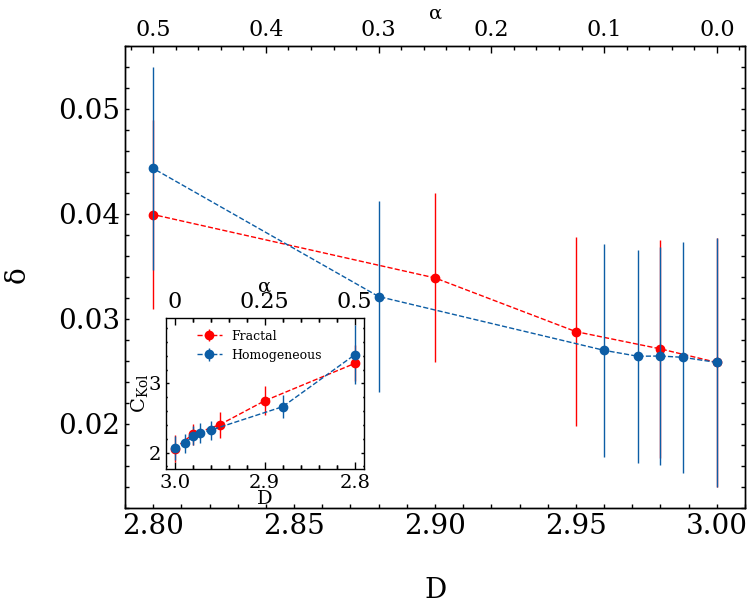

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------------
# FIGURE SETUP
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi = 100)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 2,
    'xtick.minor.size': 3,
    'ytick.minor.size': 1,
    'legend.frameon': False,
    'mathtext.default': 'regular',
})

ax.tick_params(
    axis='both',
    which='both',
    labelsize=22,   
    length=3,
    width=1,
    top=True,
    right=True
)


# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]
colors = [
    "#03045e",  # deep purple
    "#1f6fb2",  # deep blue
    "#2d6a4f",  # deep teal
    "#f9c74f",  # warm yellow (kept minimal)
    "#f3722c",  # deep orange
    "#9e2a2b",  # deep red
]
markers = ['o', 's', 'D', '*', '^', '.', '<']

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']

# ---------- Plot curves ----------




axmain_top = ax.twiny()

axmain_top.errorbar(alphas , -delta_hom/2,  delta_hom_error, fmt = 'o--'   , lw = 1 , label = 'Homogeneous')
plt.gca().invert_xaxis()

ax.errorbar(Dims, -delta_frac/2 , delta_frac_error, fmt = 'o--' ,color= 'red', ecolor= 'red', lw = 1 , label = 'Fractal')


ax.set_xlabel(r'$D$', labelpad=-1, size = 14)
axmain_top.set_xlabel(r'$\alpha$', labelpad=-0.1, size = 14)



# -----------------------------
# MAIN AXES FORMATTING
# -----------------------------
# ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))

ax.set_xlabel(r'$D$', labelpad=-15, size = 20)
ax.xaxis.set_label_coords(0.5, -0.15) # x=0.5 (center), y=-0.1 (below axis)

ax.set_ylabel(r'$\delta$', size = 20)
ax.yaxis.set_label_coords(-0.15, 0.5) # x=0.5 (center), y=-0.1 (below axis)

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------#
# -----------------------------
# INSET: LOCAL LOG SLOPES
# -----------------------------


axins = inset_axes(
    ax,
    width="45%",
    height="44%",
    loc="upper right",
    bbox_to_anchor=(-0.325, -0.33,  0.71, 0.74),   # full axes bbox
    bbox_transform=ax.transAxes,
    borderpad=0.0
)


ax.tick_params(
    axis='both',
    which='both',
    labelsize=20   
)

axins.tick_params(
    axis='both',
    which='both',
    labelsize=14   
)

ax_top = axins.twiny()

ax_top.errorbar(alphas , c_kol_hom , c_kol_hom_error, fmt = 'o--'   , lw = 1 , label = 'Homogeneous')
axins.errorbar(Dims, c_kol_frac , c_kol_frac_error, fmt = 'o--' ,color= 'red', ecolor= 'red' , lw = 1 , label = 'Fractal')

ax_top.set_xticks((0,0.25,0.5))
ax_top.set_xticklabels([0,0.25,0.5])

plt.gca().invert_xaxis()


axins.legend(loc='upper left', bbox_to_anchor=(0.1, 1),fontsize=9)


axins.set_xlabel(r'$D$', labelpad=-1, size = 14)
ax_top.set_xlabel(r'$\alpha$', labelpad=-0.1, size = 14)

axins.set_ylabel(r'$C_{Kol}$', labelpad=-1, size = 14)


plt.savefig("C_Kol.png", dpi=250, bbox_inches='tight', pad_inches=0.01)
plt.show()

# Mean Dissipation

In [37]:
u_real_field = np.load('Fractal_velocity_field_Real/Decimated_Fractal_D_2p80.npz')['u_real']
u_spec_field = np.fft.rfftn(u_real_field, axes = (1,2,3))

nu = 1e-3

In [38]:
np.fft.irfftn(u_spec_field[0]*k_vec[0] + u_spec_field[1]*k_vec[1] + u_spec_field[2]*k_vec[2]).max()

np.float64(3.9176027616420075e-12)

In [39]:
sxy = 0.5*(np.fft.irfftn(1j*k_vec[0]*u_spec_field[1]) + np.fft.irfftn(1j*k_vec[1]*u_spec_field[0]))

sxz = 0.5*(np.fft.irfftn(1j*k_vec[0]*u_spec_field[2]) + np.fft.irfftn(1j*k_vec[2]*u_spec_field[0]))

szy = 0.5*(np.fft.irfftn(1j*k_vec[2]*u_spec_field[1]) + np.fft.irfftn(1j*k_vec[1]*u_spec_field[2]))

sxx = (np.fft.irfftn(1j*k_vec[0]*u_spec_field[0]))
syy = (np.fft.irfftn(1j*k_vec[1]*u_spec_field[1]))
szz = (np.fft.irfftn(1j*k_vec[2]*u_spec_field[2]))

mean_dissp = 2*nu*( 2*np.mean(sxy**2) + 2*np.mean(sxz**2) + 2*np.mean(szy**2)  + np.mean(sxx**2) + np.mean(syy**2) + np.mean(szz**2))

mean_dissp

np.float64(0.8707172051312734)

In [14]:
def curl_func(a, k = k ):

    return  np.fft.irfftn(jnp.stack([
        1j * (k_vec[1] * a[2] - k_vec[2] * a[1]),
        1j * (k_vec[2] * a[0] - k_vec[0] * a[2]),
        1j * (k_vec[0] * a[1] - k_vec[1] * a[0]) ]),axes=(1,2,3))

In [40]:
omega = curl_func(u_spec_field)

avg_dissp = nu*np.mean(np.sum(omega**2,0))

avg_dissp

np.float64(0.8707172051312746)

# Fluxes $\Pi_k$:

In [16]:
def cross_func(a, b):
    return np.fft.rfftn(jnp.stack([
        a[1]*b[2] - a[2]*b[1],
        a[2]*b[0] - a[0]*b[2],
        a[0]*b[1] - a[1]*b[0]]), axes=(1,2,3))


def Calc_nonlinear_term(u_real , u_spec):

    nonlinear_term = cross_func(u_real, curl_func(u_spec))
   
    return  alias_mask*(nonlinear_term - jnp.sum(nonlinear_term*k_over_k_sq,0)*k_vec)



def Energy_spectra(x):
    return np.histogram(k.ravel(),bins = shells,weights=x.ravel())[0]

In [41]:
NL_term = Calc_nonlinear_term(u_real_field , u_spec_field)

In [42]:
normalize = np.where((k_vec[2] == 0) + (k_vec[2] == N//2) , 1/N**6,2/N**6)


Pik = np.real(np.conjugate(u_spec_field[0])*NL_term[0]+np.conjugate(u_spec_field[1])*NL_term[1]+ np.conjugate(u_spec_field[2])*NL_term[2])*alias_mask*normalize
Pik_arr = Energy_spectra(Pik)
Pik_arr = np.cumsum(Pik_arr[::-1])[::-1]


# np.savez('Energy_Fluz_Decimated_Fractal_D2p80.npz',Pi_k = Pik_arr, avg_dissp = avg_dissp )

In [17]:
# HOMOGENEOUS

# Pi_k = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p0.npz')['Pi_k']])

# Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p03.npz')['Pi_k']],axis =0)
 
# Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p05.npz')['Pi_k']],axis =0)

# Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p07.npz')['Pi_k']],axis =0)

# Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p1.npz')['Pi_k']],axis =0)

# Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p3.npz')['Pi_k']],axis =0)

# Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p5.npz')['Pi_k']],axis =0)



# Fractal

Pi_k = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D3p0.npz')['Pi_k']])

Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p98.npz')['Pi_k']],axis =0)
 
Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p95.npz')['Pi_k']],axis =0)

Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p90.npz')['Pi_k']],axis =0)

Pi_k  = np.append(Pi_k , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p80.npz')['Pi_k']],axis =0)


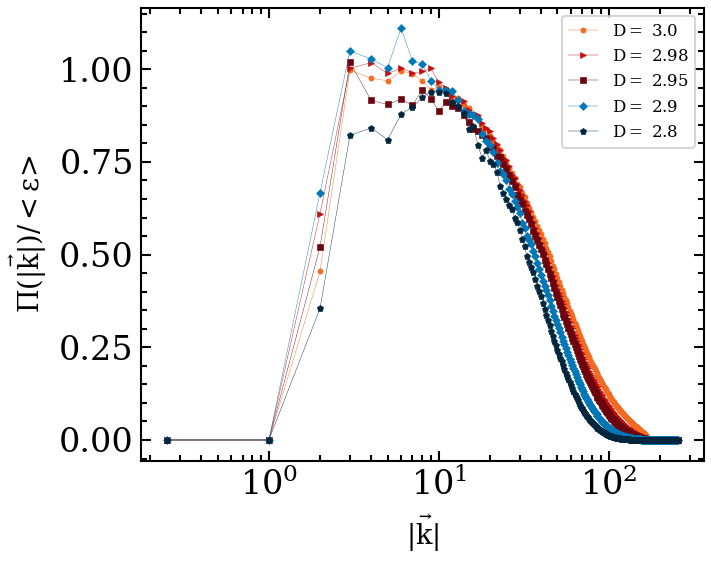

In [18]:
# ---------- Style setup ----------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.frameon': False,
    'mathtext.default': 'regular',
})

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(5,4), dpi=150)

ax.set_xlabel(r'$|\vec k|$', labelpad=5)
ax.set_ylabel(r'$\Pi(|\vec k|)/<\epsilon$>', labelpad=5)
# ax.set_title(r'Compensated Energy Spectrum (Homogeneous)', pad=8, fontsize = 9)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]

colors = ['#f9c74f', '#fbb040', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]


markers = ['o', 's', 'D', '*', '^', '.', '<']

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

Dim = [3.0 , 2.98 , 2.95 , 2.90 , 2.8]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']
ms =  [2.5,3,2.5,2.5,3,3,3.4]

# ---------- Plot curves ----------
for i in range(0,5):
    ax.plot(
        (0.5*shells[1:] + 0.5*shells[:-1]),
        Pi_k[i]/avg_dissp[i],
        marker=markers[i],
        markersize= ms[i],
        linewidth=0.2,
        color=colors[2 + i],
        label=fr'$D = $ {Dim[i]}',
        markeredgewidth=0.3,   # thinner marker border

    )


# ---------- Limits, scales, and grid ----------
# ax.set_ylim(3e1, 5e3)
# ax.set_xlim(0.25, kvals[100])
ax.set_xscale('log')
# ---------- Legend ----------
ax.legend(
    loc='best',
    handlelength=1.8,
    frameon=True,
    prop={'size': 8}
)

# ---------- Save ----------

# plt.axvline(50, lw = 1,c = 'black')
# plt.axvline(140, lw = 1,c = 'black')

plt.tight_layout()
plt.savefig('Semilog_y_Energy_Spectrum.png', dpi = 800,bbox_inches='tight')
plt.show()
